In [2]:
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score,
                             mean_absolute_error, mean_squared_error, r2_score)
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.metrics import pairwise_distances, silhouette_score
from sklearn.metrics.pairwise import cosine_similarity

from sklearn.model_selection import StratifiedKFold, train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [3]:
df = pd.read_csv('/Users/user/Documents/master/semester3/Thesis/IPIP-FFM-data-8Nov2018/data-final.csv', sep="\t")  
#data.head()
#data.describe()

In [4]:
print("Shape:", df.shape)
print(df.head(3))
print(df.dtypes.value_counts())
print("Missing % per column:\n", df.isna().mean().sort_values(ascending=False).head(10))
print("Duplicate rows:", df.duplicated().sum())

Shape: (1015341, 110)
   EXT1  EXT2  EXT3  EXT4  EXT5  EXT6  EXT7  EXT8  EXT9  EXT10  ...  \
0   4.0   1.0   5.0   2.0   5.0   1.0   5.0   2.0   4.0    1.0  ...   
1   3.0   5.0   3.0   4.0   3.0   3.0   2.0   5.0   1.0    5.0  ...   
2   2.0   3.0   4.0   4.0   3.0   2.0   1.0   3.0   2.0    5.0  ...   

              dateload  screenw  screenh  introelapse  testelapse  endelapse  \
0  2016-03-03 02:01:01    768.0   1024.0          9.0       234.0          6   
1  2016-03-03 02:01:20   1360.0    768.0         12.0       179.0         11   
2  2016-03-03 02:01:56   1366.0    768.0          3.0       186.0          7   

   IPC  country  lat_appx_lots_of_err  long_appx_lots_of_err  
0    1       GB               51.5448                 0.1991  
1    1       MY                3.1698                101.706  
2    1       GB               54.9119                -1.3833  

[3 rows x 110 columns]
float64    104
object       4
int64        2
Name: count, dtype: int64
Missing % per column:
 in

In [5]:
# --- 1. Filter for unique respondents and at least 1 minute spent on test
df = df[df["IPC"] == 1].copy()
df = df[df["testelapse"] >= 60] 

# --- 2. Define keying scheme (per IPIP-FFM key)
EXT_pos = ["EXT1","EXT3","EXT5","EXT7","EXT9"]
EXT_rev = ["EXT2","EXT4","EXT6","EXT8","EXT10"]

EST_pos = ["EST2","EST4"]           # Emotional stability (reverse of neuroticism)
EST_rev = ["EST1","EST3","EST5","EST6","EST7","EST8","EST9","EST10"]

AGR_pos = ["AGR2","AGR4","AGR6","AGR8","AGR9","AGR10"]
AGR_rev = ["AGR1","AGR3","AGR5","AGR7"]

CSN_pos = ["CSN1","CSN3","CSN5","CSN7","CSN9","CSN10"]
CSN_rev = ["CSN2","CSN4","CSN6","CSN8"]

OPN_pos = ["OPN1","OPN3","OPN5","OPN7","OPN8","OPN9","OPN10"]
OPN_rev = ["OPN2","OPN4","OPN6"]

# Keep only columns that actually exist
def keep_existing(cols): return [c for c in cols if c in df.columns]
EXT_pos, EXT_rev = keep_existing(EXT_pos), keep_existing(EXT_rev)
EST_pos, EST_rev = keep_existing(EST_pos), keep_existing(EST_rev)
AGR_pos, AGR_rev = keep_existing(AGR_pos), keep_existing(AGR_rev)
CSN_pos, CSN_rev = keep_existing(CSN_pos), keep_existing(CSN_rev)
OPN_pos, OPN_rev = keep_existing(OPN_pos), keep_existing(OPN_rev)

# --- 3. Reverse-key negatively worded items so higher = more of trait
# Assuming original scale is 1..5
def reverse_key(series, min_val=1, max_val=5):
    return (max_val + min_val) - series

for col in EXT_rev + EST_rev + AGR_rev + CSN_rev + OPN_rev:
    if col in df.columns:
        df[col] = reverse_key(df[col])

# --- 4. Compute Big Five scores (mean of keyed items)
df["extraversion"]         = df[EXT_pos + EXT_rev].mean(axis=1)
df["emotional_stability"]  = df[EST_pos + EST_rev].mean(axis=1)
df["agreeableness"]        = df[AGR_pos + AGR_rev].mean(axis=1)
df["conscientiousness"]    = df[CSN_pos + CSN_rev].mean(axis=1)
df["openness"]             = df[OPN_pos + OPN_rev].mean(axis=1)

big5_cols = ["extraversion","agreeableness","conscientiousness","emotional_stability","openness"]

print(df[big5_cols].describe().T)


                        count      mean       std  min  25%  50%  75%  max
extraversion         692712.0  2.919968  0.908047  0.8  2.2  2.9  3.6  5.5
agreeableness        692712.0  3.751434  0.736542  0.8  3.3  3.8  4.3  5.2
conscientiousness    692712.0  3.335245  0.739039  0.9  2.8  3.3  3.9  5.2
emotional_stability  692712.0  2.922178  0.860306  0.8  2.3  2.9  3.5  5.6
openness             692712.0  3.920966  0.624848  0.9  3.5  4.0  4.4  5.2


In [6]:
df["country"].value_counts().head(20)

country
US      344152
GB       49612
CA       43670
AU       34551
DE       12271
IN       12062
PH       10970
MX        9741
NONE      9543
NO        8540
NL        7707
SE        7417
MY        7232
NZ        6511
ID        5551
BR        5397
SG        5261
FR        5107
IT        4403
ES        4327
Name: count, dtype: int64


Summary statistics (1–5 scale expected):


,count,mean,std,min,25%,50%,75%,max
extraversion,692712.0,2.919968,0.908047,0.8,2.2,2.9,3.6,5.5
agreeableness,692712.0,3.751434,0.736542,0.8,3.3,3.8,4.3,5.2
conscientiousness,692712.0,3.335245,0.739039,0.9,2.8,3.3,3.9,5.2
emotional_stability,692712.0,2.922178,0.860306,0.8,2.3,2.9,3.5,5.6
openness,692712.0,3.920966,0.624848,0.9,3.5,4.0,4.4,5.2


<Figure size 1000x600 with 0 Axes>

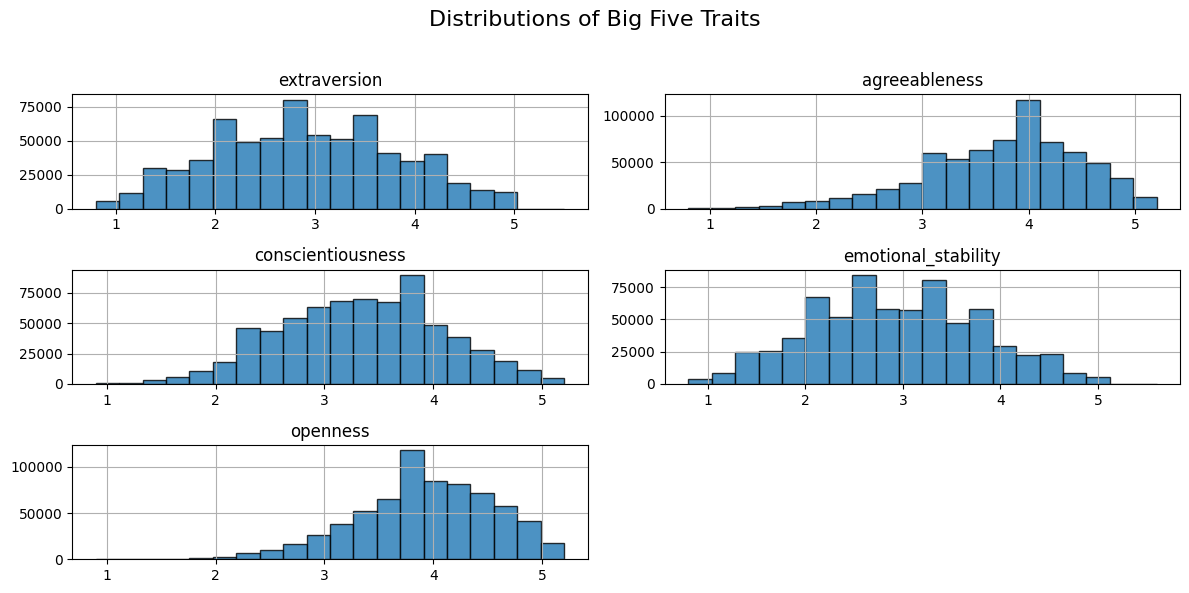

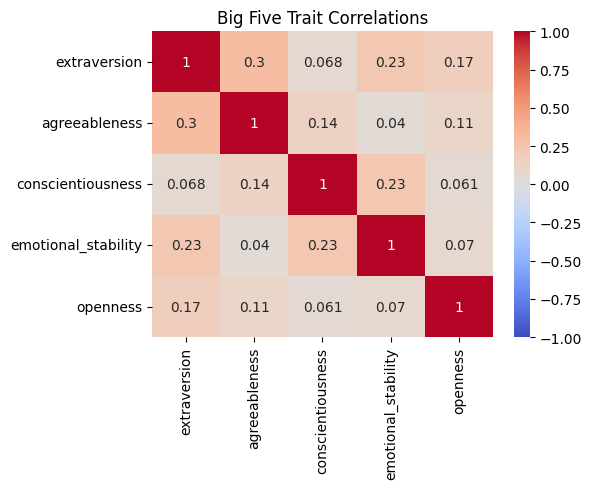

/var/folders/pw/5l91wv7n48d7b73s55jy4bf40000gn/T/ipykernel_12118/4213975864.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette="Blues_r")


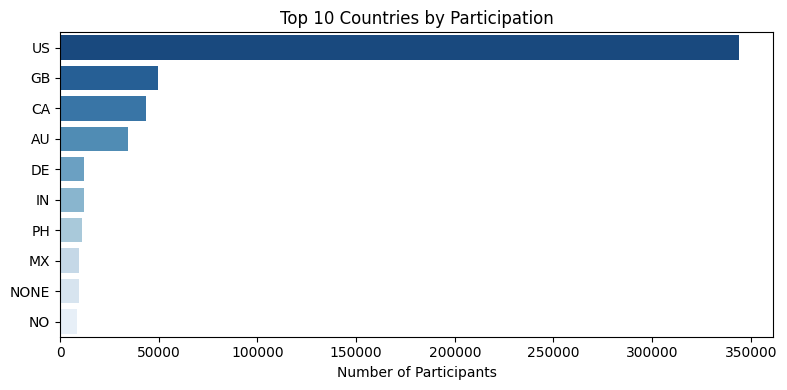

Top 10 countries:
 country
US      344152
GB       49612
CA       43670
AU       34551
DE       12271
IN       12062
PH       10970
MX        9741
NONE      9543
NO        8540
Name: count, dtype: int64


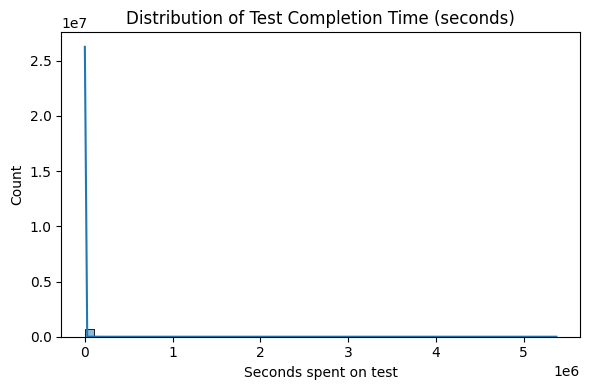

count    6.927120e+05
mean     6.529334e+02
std      1.589551e+04
min      6.000000e+01
10%      1.390000e+02
50%      2.210000e+02
90%      4.750000e+02
max      5.372971e+06
Name: testelapse, dtype: float64


In [7]:
# 2. Descriptive stats for Big Five
# -------------------------------------------------
big5_cols = ["extraversion","agreeableness","conscientiousness","emotional_stability","openness"]
print("\nSummary statistics (1–5 scale expected):")
display(df[big5_cols].describe().T)

# -------------------------------------------------
# 3. Trait distributions
# -------------------------------------------------
plt.figure(figsize=(10,6))
df[big5_cols].hist(bins=20, figsize=(12,6), edgecolor="black", alpha=0.8)
plt.suptitle("Distributions of Big Five Traits", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# -------------------------------------------------
# 4. Correlation matrix
# -------------------------------------------------
corr = df[big5_cols].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Big Five Trait Correlations")
plt.tight_layout()
plt.show()

# -------------------------------------------------
# 5. Country distribution (if available)
# -------------------------------------------------
if "country" in df.columns:
    top_countries = df["country"].value_counts().head(10)
    plt.figure(figsize=(8,4))
    sns.barplot(x=top_countries.values, y=top_countries.index, palette="Blues_r")
    plt.title("Top 10 Countries by Participation")
    plt.xlabel("Number of Participants")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()
    print("Top 10 countries:\n", top_countries)

# -------------------------------------------------
# 6. Test duration stats (if available)
# -------------------------------------------------
if "testelapse" in df.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df["testelapse"], bins=50, kde=True)
    plt.title("Distribution of Test Completion Time (seconds)")
    plt.xlabel("Seconds spent on test")
    plt.tight_layout()
    plt.show()
    print(df["testelapse"].describe(percentiles=[.1,.5,.9]))


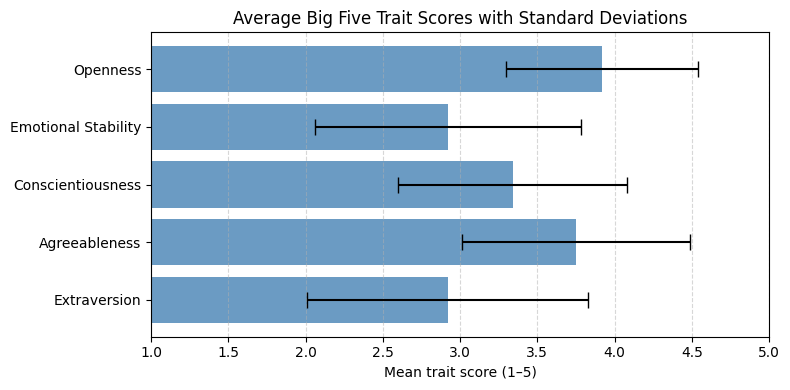

In [8]:
traits = ["Extraversion", "Agreeableness", "Conscientiousness", "Emotional Stability", "Openness"]
means = [2.92, 3.75, 3.34, 2.92, 3.92]
stds  = [0.91, 0.74, 0.74, 0.86, 0.62]

fig, ax = plt.subplots(figsize=(8, 4))
y_pos = np.arange(len(traits))

ax.barh(y_pos, means, xerr=stds, capsize=6, color="steelblue", alpha=0.8)
ax.set_yticks(y_pos)
ax.set_yticklabels(traits)
ax.set_xlabel("Mean trait score (1–5)")
ax.set_xlim(1, 5)
ax.set_title("Average Big Five Trait Scores with Standard Deviations")
ax.grid(axis="x", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


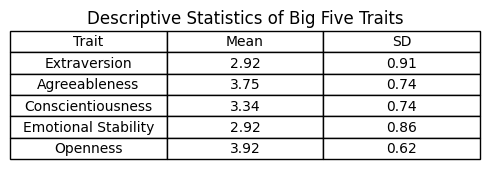

In [9]:
data = [
    ["Extraversion", 2.92, 0.91],
    ["Agreeableness", 3.75, 0.74],
    ["Conscientiousness", 3.34, 0.74],
    ["Emotional Stability", 2.92, 0.86],
    ["Openness", 3.92, 0.62]
]

fig, ax = plt.subplots(figsize=(5, 1.8))
ax.axis("off")
table = ax.table(
    cellText=data,
    colLabels=["Trait", "Mean", "SD"],
    cellLoc="center",
    loc="center"
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.4)
plt.title("Descriptive Statistics of Big Five Traits", fontsize=12)
plt.tight_layout()
plt.show()


/var/folders/pw/5l91wv7n48d7b73s55jy4bf40000gn/T/ipykernel_12118/2848294725.py:21: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  y /= np.trapz(y, x_grid)   # normalize for comparability


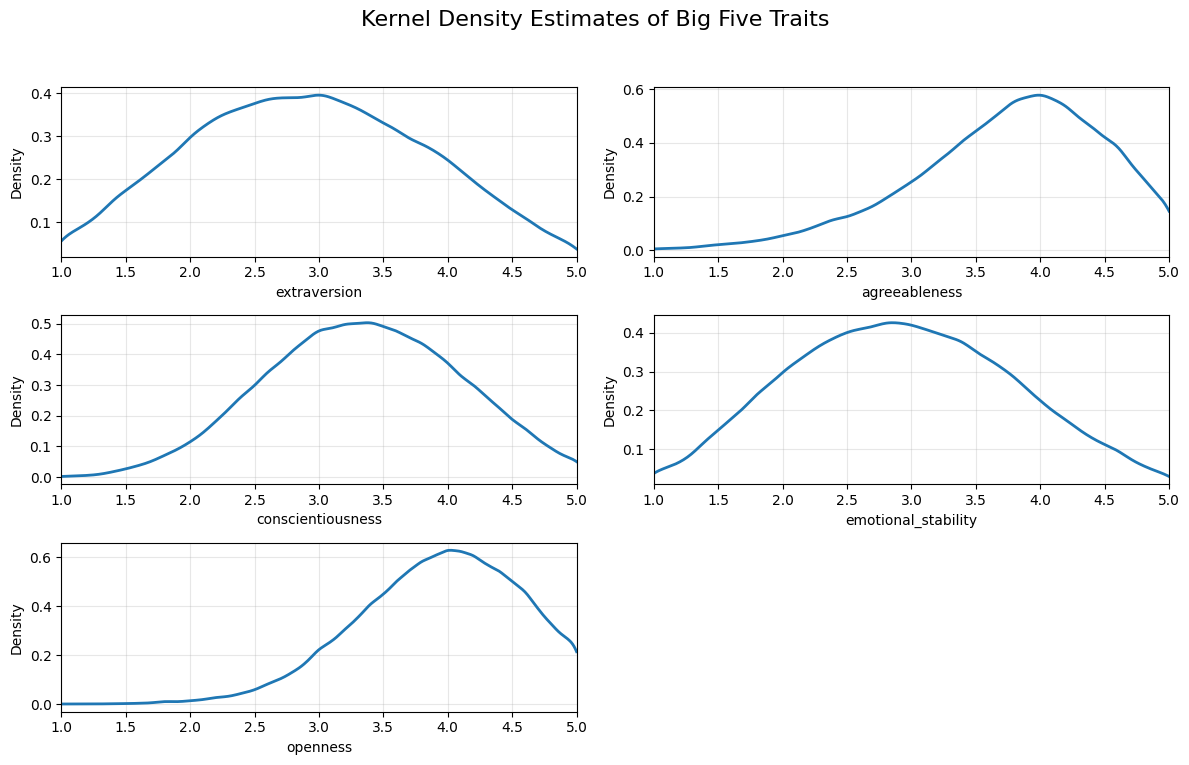

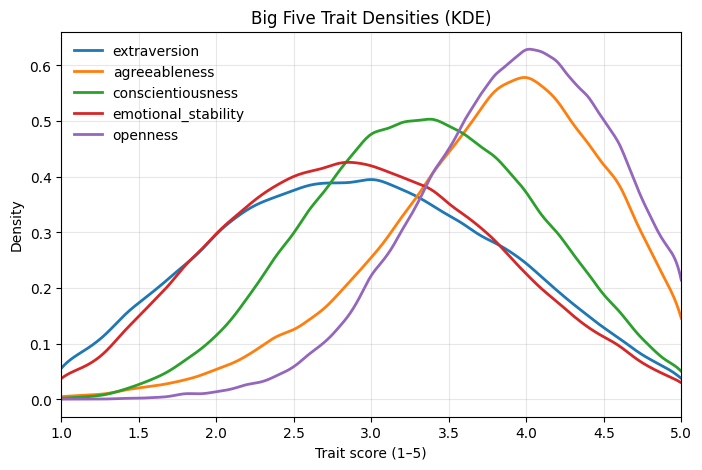

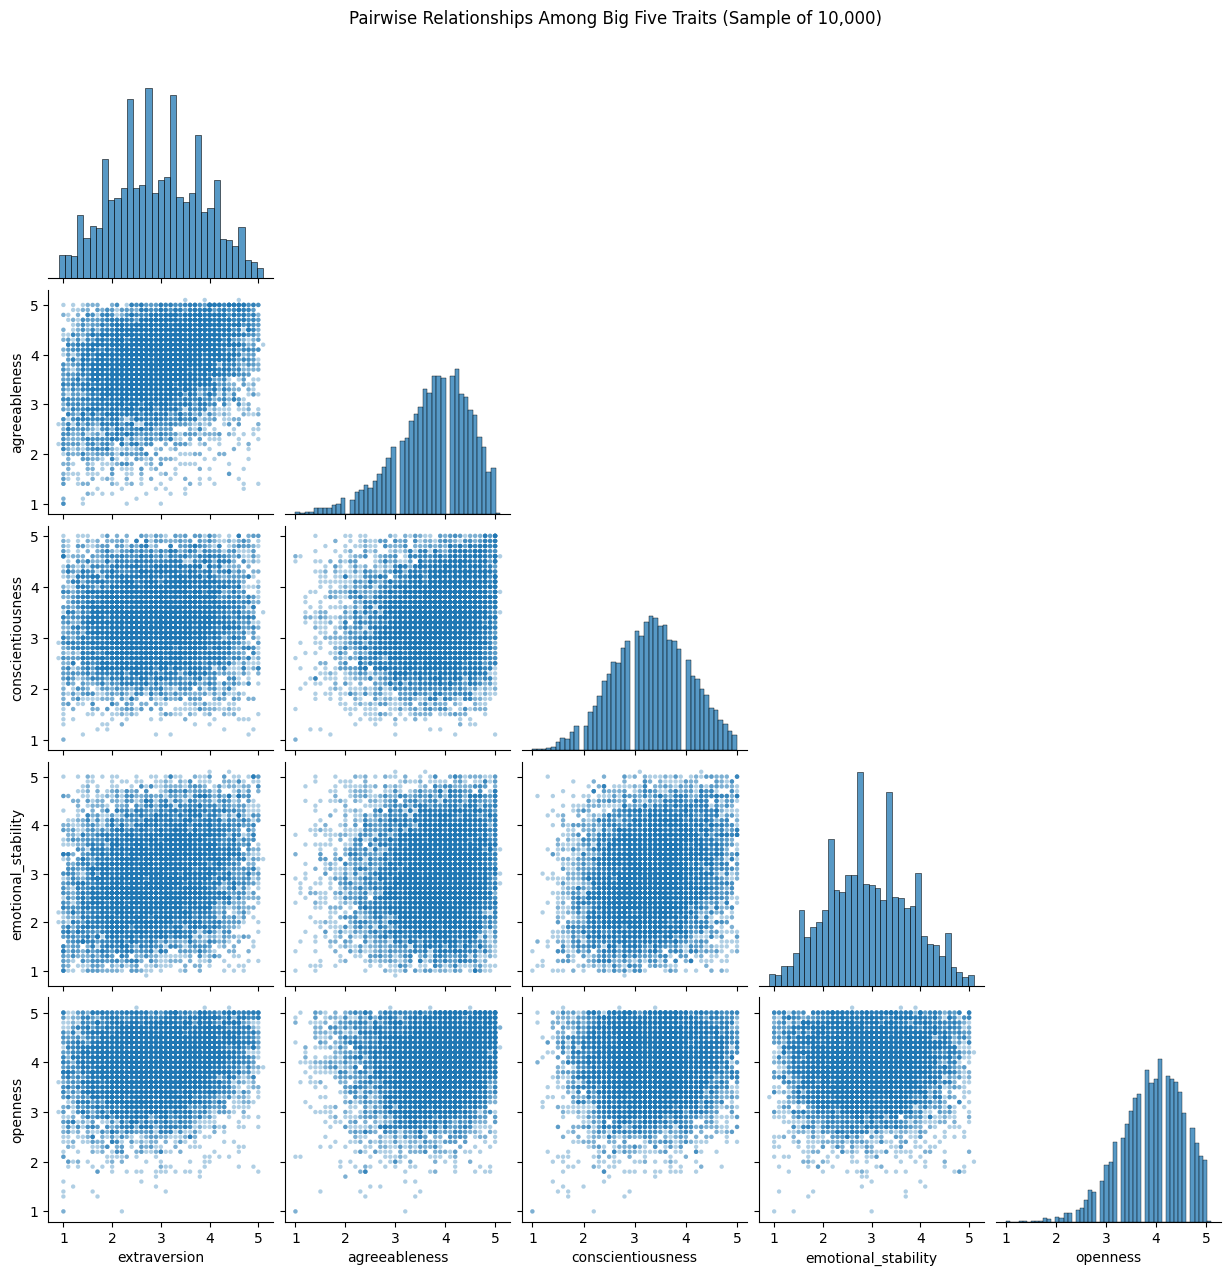

In [10]:
# EDA parameters for KDE & Pairwise scatterplot
RANDOM_STATE = 42
EDA_N       = 120_000   # master EDA sample size (set to None for full data)
SCATTER_N   = 10_000    # deterministic subset for pairplot (kept consistent)

# 0) Build the master EDA dataframe once
if EDA_N is None or len(df) <= EDA_N:
    eda_df = df[big5_cols].dropna().copy()
else:
    eda_df = df[big5_cols].dropna().sample(EDA_N, random_state=RANDOM_STATE)

# Deterministic subset for pairplot only (keeps coherence)
eda_scatter_df = eda_df.sample(min(SCATTER_N, len(eda_df)), random_state=RANDOM_STATE)

# 1) KDEs (no seaborn): smooth density on 1..5 scale
x_grid = np.linspace(1, 5, 400)

def kde_curve(x):
    kde = gaussian_kde(x, bw_method="silverman")
    y = kde.evaluate(x_grid)
    y /= np.trapz(y, x_grid)   # normalize for comparability
    return y

# Grid of individual KDEs
fig, axes = plt.subplots(3, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(big5_cols):
    y = kde_curve(eda_df[col].values)
    axes[i].plot(x_grid, y, linewidth=2)
    axes[i].set_xlim(1, 5)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")
    axes[i].grid(True, alpha=0.3)
axes[-1].axis("off")
fig.suptitle("Kernel Density Estimates of Big Five Traits", fontsize=16)
fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# Overlay KDEs
plt.figure(figsize=(8,5))
for col in big5_cols:
    y = kde_curve(eda_df[col].values)
    plt.plot(x_grid, y, linewidth=2, label=col)
plt.xlim(1,5)
plt.xlabel("Trait score (1–5)")
plt.ylabel("Density")
plt.title("Big Five Trait Densities (KDE)")
plt.grid(True, alpha=0.3)
plt.legend(frameon=False)
plt.show()

# 2) Pairwise scatterplot (deterministic subset of the master sample)
sns.pairplot(
    eda_scatter_df[big5_cols],
    corner=True,                 # half-matrix; faster & cleaner
    diag_kind="hist",
    plot_kws=dict(alpha=0.35, s=10, edgecolor="none")
)
plt.suptitle(
    f"Pairwise Relationships Among Big Five Traits (Sample of {len(eda_scatter_df):,})",
    y=1.02
)
plt.show()


Explained variance ratio: [0.321 0.207]
Total explained variance (2 PCs): 0.528


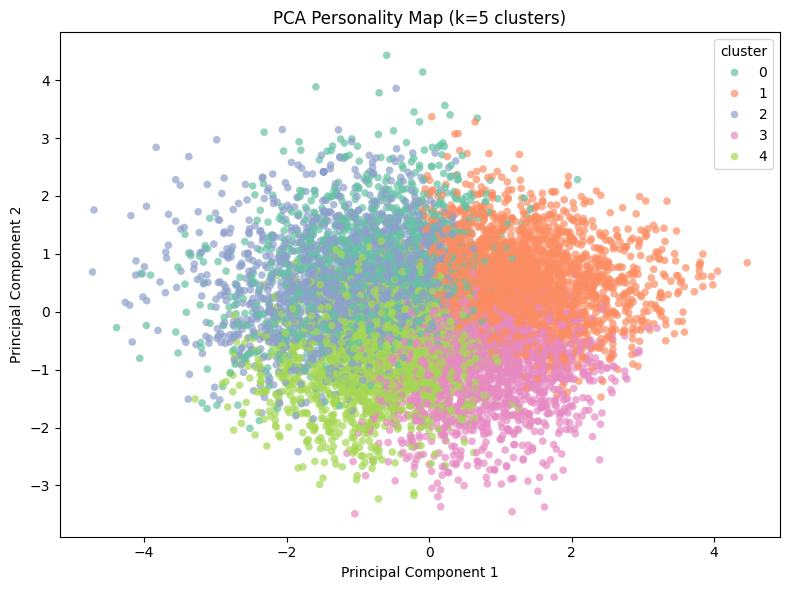

,extraversion,agreeableness,conscientiousness,emotional_stability,openness
cluster,,,,,
0,2.36,2.70,3.34,3.16,4.18
1,3.36,4.21,4.04,3.51,4.01
2,2.49,3.47,3.10,2.68,3.08
3,3.85,4.07,2.81,3.03,4.19
4,2.31,3.95,3.15,2.09,4.16


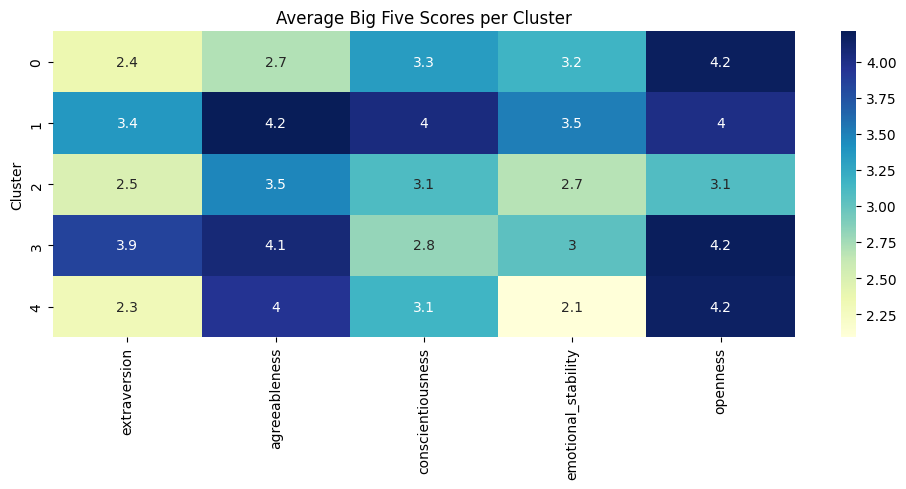

In [11]:
# -----------------------------
# 1. Prepare data
# -----------------------------
big5_cols = ["extraversion","agreeableness","conscientiousness","emotional_stability","openness"]
df_big5 = df[big5_cols].dropna().copy()

# Subsample for speed
sample_n = 10000  # Adjust (5k–20k works well)
df_sample = df_big5.sample(sample_n, random_state=42)

# Scale data before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_sample)

# -----------------------------
# 2. PCA
# -----------------------------
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(X_pca, columns=["PC1", "PC2"])

print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 3))
print("Total explained variance (2 PCs):", round(pca.explained_variance_ratio_.sum(), 3))

# -----------------------------
# 3. KMeans clustering
# -----------------------------
k = 5  # You can test 4–8 clusters to explore personality archetypes
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
df_pca["cluster"] = kmeans.fit_predict(X_scaled)

# -----------------------------
# 4. Visualization
# -----------------------------
plt.figure(figsize=(8,6))
palette = sns.color_palette("Set2", k)
sns.scatterplot(data=df_pca, x="PC1", y="PC2", hue="cluster", palette=palette, alpha=0.7, s=30, edgecolor="none")
plt.title(f"PCA Personality Map (k={k} clusters)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

# -----------------------------
# 5. Trait profiles per cluster
# -----------------------------
df_sample["cluster"] = df_pca["cluster"].values
cluster_means = df_sample.groupby("cluster")[big5_cols].mean().round(2)
display(cluster_means)

plt.figure(figsize=(10,5))
sns.heatmap(cluster_means, annot=True, cmap="YlGnBu")
plt.title("Average Big Five Scores per Cluster")
plt.ylabel("Cluster")
plt.tight_layout()
plt.show()


In [12]:


# ---------------------------
# CONFIG
# ---------------------------

# Columns expected in df (adjust names if yours differ)
BIG5_COLS = {
    "extraversion": "extraversion",
    "agreeableness": "agreeableness",
    "conscientiousness": "conscientiousness",
    "emotional_stability": "emotional_stability",
    "openness": "openness",
}

# Which traits are treated as "similarity" vs. "complementarity"
SIMILARITY_TRAITS = ["agreeableness", "conscientiousness", "openness"]
COMPLEMENTARITY_TRAITS = ["extraversion", "emotional_stability"]

# Weights across traits (sum does not need to be 1; we normalize internally)
TRAIT_WEIGHTS = {
    "agreeableness": 1.0,
    "conscientiousness": 1.0,
    "openness": 0.8,
    "extraversion": 0.8,
    "emotional_stability": 1.0,
}

# Score scale (IPIP 1..5)
SCALE_MIN, SCALE_MAX = 1.0, 5.0
DELTA_MAX = SCALE_MAX - SCALE_MIN  # 4.0
# For complementarity we prefer a moderate difference (e.g., ~1 point apart)
IDEAL_DELTA = 1.0  # tune between ~0.5 and 1.5 if you wish


# ---------------------------
# CORE SCORING FUNCTIONS
# ---------------------------

def _similarity_component(a, b):
    """Similarity: higher when |a-b| is small, normalized to [0,1]."""
    return np.clip(1.0 - np.abs(a - b) / DELTA_MAX, 0.0, 1.0)

def _complementarity_component(a, b, ideal_delta=IDEAL_DELTA):
    """
    Complementarity: favors moderate |a-b| ≈ ideal_delta.
    Triangular score: 1 at ideal, decreasing linearly toward 0 at 0 or DELTA_MAX.
    """
    delta = np.abs(a - b)
    # distance from ideal, normalized to [0,1] by max possible deviation
    # max deviation from ideal is max(ideal, DELTA_MAX - ideal)
    max_dev = max(ideal_delta, DELTA_MAX - ideal_delta)
    return np.clip(1.0 - np.abs(delta - ideal_delta) / max_dev, 0.0, 1.0)

def compatibility_between_rows(row_i, row_j, weights=TRAIT_WEIGHTS):
    """
    Compute a single compatibility score between two people (rows) using the mixed rule.
    Returns a scalar in [0,1].
    """
    num, den = 0.0, 0.0
    for t in SIMILARITY_TRAITS:
        vi, vj = row_i[BIG5_COLS[t]], row_j[BIG5_COLS[t]]
        if pd.notna(vi) and pd.notna(vj):
            w = weights.get(t, 1.0)
            num += w * _similarity_component(vi, vj)
            den += w
    for t in COMPLEMENTARITY_TRAITS:
        vi, vj = row_i[BIG5_COLS[t]], row_j[BIG5_COLS[t]]
        if pd.notna(vi) and pd.notna(vj):
            w = weights.get(t, 1.0)
            num += w * _complementarity_component(vi, vj, ideal_delta=IDEAL_DELTA)
            den += w
    if den == 0:
        return np.nan
    return num / den  # normalized weighted average in [0,1]


def compatibility_matrix(df, id_col=None, weights=TRAIT_WEIGHTS):
    """
    Compute the full N x N compatibility matrix.
    - df: DataFrame with Big Five columns present
    - id_col: optional column to use as index/labels; else use df.index
    Returns: (comp_df, labels)
    """
    # Ensure required columns exist
    missing = [c for c in BIG5_COLS.values() if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    # Prepare labels
    labels = df[id_col].astype(str).values if id_col and id_col in df.columns else df.index.astype(str).values

    n = len(df)
    M = np.zeros((n, n), dtype=float)
    # Vectorized-ish double loop; still O(n^2), so sample if needed
    for i in range(n):
        ri = df.iloc[i]
        M[i, i] = 1.0  # perfect self-compatibility
        for j in range(i+1, n):
            rj = df.iloc[j]
            s = compatibility_between_rows(ri, rj, weights=weights)
            M[i, j] = s
            M[j, i] = s
    comp_df = pd.DataFrame(M, index=labels, columns=labels)
    return comp_df, labels


# ---------------------------
# UTILITIES
# ---------------------------

def top_matches(comp_df, k=5, exclude_self=True):
    """
    For each row in comp_df, return top-k matches (label, score).
    Returns dict: label -> list[(label_j, score_j), ...]
    """
    results = {}
    for i, idx in enumerate(comp_df.index):
        scores = comp_df.loc[idx].copy()
        if exclude_self and idx in scores.index:
            scores = scores.drop(idx, errors="ignore")
        topk = scores.sort_values(ascending=False).head(k)
        results[idx] = list(zip(topk.index.tolist(), topk.values.tolist()))
    return results


def group_harmony(comp_df, group_members):
    """
    Compute within-group (e.g., apartment) average compatibility.
    - comp_df: square compatibility matrix with labels as index/columns
    - group_members: dict like {"Apt-101": ["id1","id2","id3"], ...}
    Returns DataFrame with columns:
      group, n_members, pairs_count, mean_compat, median_compat
    """
    rows = []
    for g, members in group_members.items():
        members = [m for m in members if m in comp_df.index]
        m = len(members)
        if m < 2:
            rows.append({"group": g, "n_members": m, "pairs_count": 0,
                         "mean_compat": np.nan, "median_compat": np.nan})
            continue
        # collect upper-triangle pair scores
        vals = []
        for i in range(m):
            for j in range(i+1, m):
                vals.append(comp_df.loc[members[i], members[j]])
        vals = np.array(vals, dtype=float)
        rows.append({
            "group": g,
            "n_members": m,
            "pairs_count": len(vals),
            "mean_compat": float(np.nanmean(vals)),
            "median_compat": float(np.nanmedian(vals)),
        })
    return pd.DataFrame(rows).sort_values("mean_compat", ascending=False).reset_index(drop=True)


In [13]:
palette = sns.color_palette("Set2", k)

# Cosine similarity on standardized data
sim_matrix = cosine_similarity(X_scaled)

# Convert to DataFrame for convenience
sim_df = pd.DataFrame(sim_matrix, columns=df_sample.index, index=df_sample.index)

# Assign cluster labels for grouping
df_sample["cluster"] = df_pca["cluster"].values

# Compute average within- and between-cluster similarities
cluster_labels = df_sample["cluster"].values
clusters = sorted(df_sample["cluster"].unique())

inter_cluster_sim = np.zeros((k, k))

for i, ci in enumerate(clusters):
    for j, cj in enumerate(clusters):
        mask_i = df_sample["cluster"] == ci
        mask_j = df_sample["cluster"] == cj
        sub = sim_matrix[np.ix_(mask_i, mask_j)]
        inter_cluster_sim[i, j] = np.mean(sub)

# Convert to DataFrame for plotting
inter_cluster_df = pd.DataFrame(inter_cluster_sim, index=[f"C{i}" for i in clusters], columns=[f"C{j}" for j in clusters])

In [14]:
# Silhouette score (overall cluster cohesion)
silhouette_avg = silhouette_score(X_scaled, df_sample["cluster"])
print(f"Silhouette score: {silhouette_avg:.3f}")

# Centroid distances in Big Five space
centroids = df_sample.groupby("cluster")[big5_cols].mean().values
centroid_dists = pairwise_distances(centroids, metric="euclidean")
centroid_df = pd.DataFrame(centroid_dists, index=[f"C{i}" for i in clusters], columns=[f"C{j}" for j in clusters])


Silhouette score: 0.156


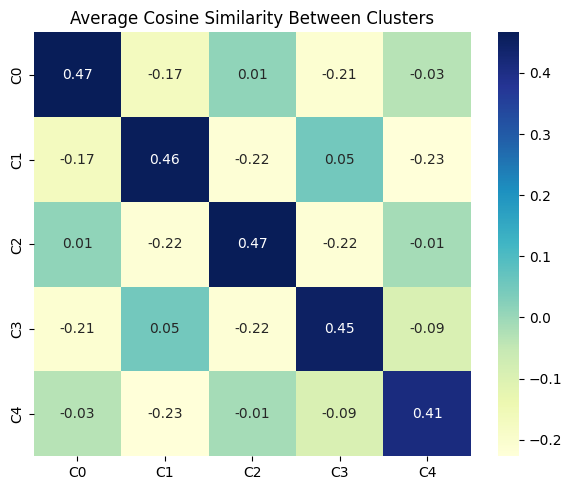

In [15]:
plt.figure(figsize=(6,5))
sns.heatmap(inter_cluster_df, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Average Cosine Similarity Between Clusters")
plt.tight_layout()
plt.show()
# plt.savefig("cluster_similarity_heatmap.png", dpi=300, bbox_inches="tight")


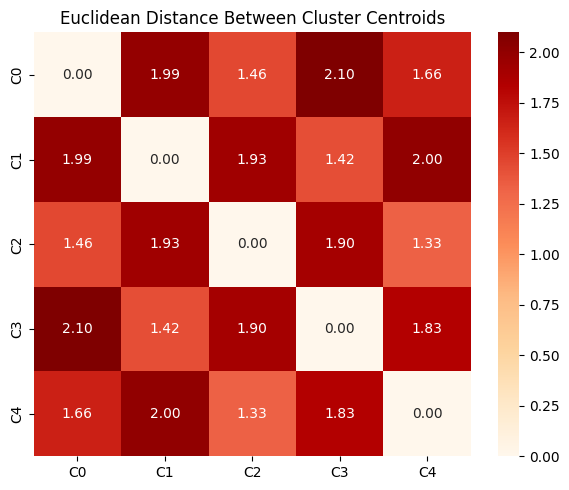

In [16]:
plt.figure(figsize=(6,5))
sns.heatmap(centroid_df, annot=True, cmap="OrRd", fmt=".2f")
plt.title("Euclidean Distance Between Cluster Centroids")
plt.tight_layout()
plt.show()
# plt.savefig("cluster_centroid_distance.png", dpi=300, bbox_inches="tight")


/var/folders/pw/5l91wv7n48d7b73s55jy4bf40000gn/T/ipykernel_12118/1881559958.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="cluster", y="similarity", data=within_df, palette=palette)


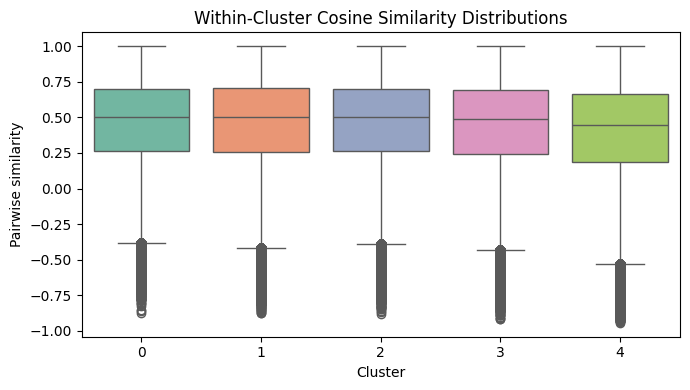

In [17]:
within_sims = []
for c in clusters:
    mask = df_sample["cluster"] == c
    sims = sim_matrix[np.ix_(mask, mask)]
    mean_within = sims[np.triu_indices_from(sims, k=1)]
    within_sims.append(pd.DataFrame({"cluster": c, "similarity": mean_within}))

within_df = pd.concat(within_sims)

plt.figure(figsize=(7,4))
sns.boxplot(x="cluster", y="similarity", data=within_df, palette=palette)
plt.title("Within-Cluster Cosine Similarity Distributions")
plt.xlabel("Cluster")
plt.ylabel("Pairwise similarity")
plt.tight_layout()
plt.show()
# plt.savefig("within_cluster_similarity_boxplot.png", dpi=300, bbox_inches="tight")


/Users/user/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/user/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/user/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Users/user/.venv/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was depr

    Model                                        Best Params  Accuracy  \
0  LogReg  {'clf__C': 3, 'clf__penalty': 'l2', 'clf__solv...    0.9965   
1     SVM  {'clf__C': 0.5, 'clf__gamma': 'scale', 'clf__k...    0.9810   
3  GBoost  {'clf__learning_rate': 0.1, 'clf__max_depth': ...    0.9570   
2      RF  {'clf__max_depth': None, 'clf__min_samples_lea...    0.9410   

   Macro-F1  
0  0.996313  
1  0.980162  
3  0.955716  
2  0.940098  

Best model: LogReg
              precision    recall  f1-score   support

           0      0.997     0.993     0.995       304
           1      0.998     1.000     0.999       497
           2      0.993     1.000     0.996       403
           3      0.995     0.997     0.996       383
           4      1.000     0.990     0.995       413

    accuracy                          0.997      2000
   macro avg      0.996     0.996     0.996      2000
weighted avg      0.997     0.997     0.996      2000



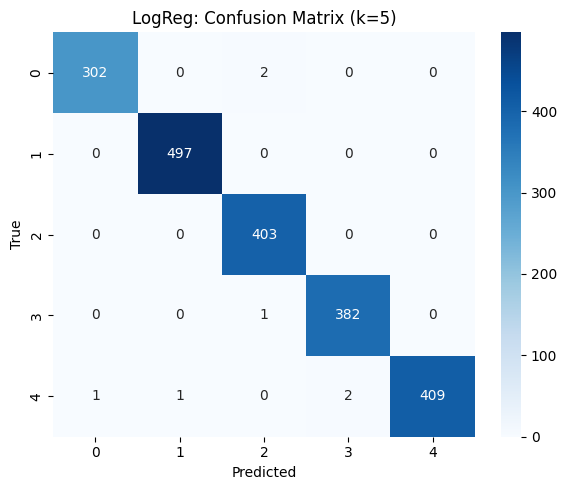

In [18]:
# Reuse your variables:
big5_cols = ["extraversion","agreeableness","conscientiousness","emotional_stability","openness"]
k = 5  # your chosen k for k-means earlier

# df_sample already created in your PCA step (10k). If not, sample deterministically:
if 'df_sample' not in globals():
    df_sample = df[big5_cols].dropna().sample(10000, random_state=42).copy()

# y = cluster labels from your previous k-means fit (df_pca["cluster"])
# If not in memory, quickly refit k-means on the same sample to regenerate y.
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler_for_k = StandardScaler()
X_k = scaler_for_k.fit_transform(df_sample[big5_cols].values)
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
y = kmeans.fit_predict(X_k)

# Final modeling matrix (keep raw values; pipelines will scale)
X = df_sample[big5_cols].copy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# -------------------------
# 1) Define models + grids
# -------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

pipelines_and_grids = [
    (
        "LogReg",
        Pipeline([("scaler", StandardScaler()),
                  ("clf", LogisticRegression(multi_class="multinomial", max_iter=2000, n_jobs=None))]),
        {
            "clf__C": [0.1, 1, 3],
            "clf__penalty": ["l2"],
            "clf__solver": ["lbfgs"]
        }
    ),
    (
        "SVM",
        Pipeline([("scaler", StandardScaler()),
                  ("clf", SVC(probability=False))]),
        {
            "clf__C": [0.5, 1, 3],
            "clf__kernel": ["rbf"],
            "clf__gamma": ["scale", 0.5, 0.25]
        }
    ),
    (
        "RF",
        Pipeline([("clf", RandomForestClassifier(random_state=42))]),
        {
            "clf__n_estimators": [200, 500],
            "clf__max_depth": [None, 8, 12],
            "clf__min_samples_leaf": [1, 3]
        }
    ),
    (
        "GBoost",
        Pipeline([("clf", GradientBoostingClassifier(random_state=42))]),
        {
            "clf__n_estimators": [200, 400],
            "clf__learning_rate": [0.05, 0.1],
            "clf__max_depth": [2, 3]
        }
    ),
]

results = []
best_models = {}

for name, pipe, grid in pipelines_and_grids:
    gs = GridSearchCV(
        pipe, grid, scoring="f1_macro", cv=cv, n_jobs=-1, verbose=0
    )
    gs.fit(X_train, y_train)
    best_models[name] = gs.best_estimator_
    y_pred = gs.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1m = f1_score(y_test, y_pred, average="macro")
    results.append((name, gs.best_params_, acc, f1m))

# Summary table
res_df = pd.DataFrame(results, columns=["Model","Best Params","Accuracy","Macro-F1"]).sort_values("Macro-F1", ascending=False)
print(res_df)

# Pick best and show detailed report + confusion matrix
best_name = res_df.iloc[0,0]
best_est = best_models[best_name]
y_pred = best_est.predict(X_test)
print(f"\nBest model: {best_name}")
print(classification_report(y_test, y_pred, digits=3))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"{best_name}: Confusion Matrix (k={k})")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.show()


In [19]:
# If df has 700,000 rows
df_sample = df.sample(n=1000, random_state=42).reset_index(drop=True)
print(df_sample.shape)


(1000, 115)


In [20]:
# Replace df by df_sample throughout the pipeline
df = df_sample
df = df.reset_index(drop=True)
df["person_id"] = df.index.astype(str)

In [21]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.neighbors import NearestNeighbors

# -------------------------------
# 0) Config / columns you gave me
# -------------------------------
big5_cols = ["extraversion","agreeableness","conscientiousness","emotional_stability","openness"]
K = 5                 # number of personality types (k-means clusters)
SAMPLE_FOR_KMEANS = 10000  # sample size to (re)fit quick KMeans + LogReg if best_est not present
MAX_SAMPLE_SIM = 2000 # sample size for similarity stage (keeps it fast)
TOP_K = 20            # top-k neighbors per person for recommendations

# -------------------------------
# 1) Ensure an ID column
# -------------------------------
if "person_id" not in df.columns:
    df = df.reset_index(drop=True)
    df["person_id"] = df.index.astype(str)

# -------------------------------
# 2) Attach pred_type
#    - If a trained classifier 'best_est' exists in memory, use it
#    - Else, fit quick KMeans on a sample, then train multinomial LogReg to predict clusters
# -------------------------------
def build_quick_logreg_classifier(df_source, cols, k=5, sample_n=10000, random_state=42):
    # sample for KMeans + LogReg training
    df_train = df_source[cols].dropna()
    if len(df_train) > sample_n:
        df_train = df_train.sample(n=sample_n, random_state=random_state).copy()

    # KMeans on standardized features to create pseudo-labels
    scaler_k = StandardScaler()
    Xk = scaler_k.fit_transform(df_train.values)
    km = KMeans(n_clusters=k, random_state=random_state, n_init=10)
    y_clusters = km.fit_predict(Xk)

    # Multinomial Logistic Regression pipeline (scaler inside)
    logreg_pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(multi_class="multinomial", max_iter=2000))
    ])
    logreg_pipe.fit(df_train.values, y_clusters)
    return logreg_pipe

# use existing best_est if present and compatible
use_existing = False
if "best_est" in globals():
    try:
        _ = best_est.predict(df[big5_cols].head(1))
        use_existing = True
    except Exception:
        use_existing = False

if use_existing:
    pred = best_est.predict(df[big5_cols])
else:
    quick_clf = build_quick_logreg_classifier(df, big5_cols, k=K, sample_n=SAMPLE_FOR_KMEANS)
    pred = quick_clf.predict(df[big5_cols])

df["pred_type"] = pred

# -------------------------------
# 3) Similarity with same_type populated
# -------------------------------
# auto-sample for the similarity stage to keep it light
if len(df) > MAX_SAMPLE_SIM:
    df_work = df.sample(n=MAX_SAMPLE_SIM, random_state=42).reset_index(drop=True)
else:
    df_work = df.copy().reset_index(drop=True)

# standardize for cosine distance
X = df_work[big5_cols].to_numpy().astype(float)
scaler = StandardScaler()
Xz = scaler.fit_transform(X)

ids = df_work["person_id"].to_numpy()
type_vals = df_work["pred_type"].to_numpy()

# top-k neighbors (cosine distance -> similarity)
nbrs = NearestNeighbors(n_neighbors=TOP_K + 1, metric='cosine')
nbrs.fit(Xz)
distances, indices = nbrs.kneighbors(Xz)

rows = []
same_type_bonus = 0.05  # small bump; tune later with Stage-2 data
diff_type_penalty = 0.00

for i in range(len(df_work)):
    neigh_ids = indices[i]
    neigh_dist = distances[i]
    for rank in range(1, len(neigh_ids)):  # skip self
        j = neigh_ids[rank]
        sim = 1.0 - float(neigh_dist[rank])
        sim = np.clip(sim, 0, 1)

        st = 1 if type_vals[i] == type_vals[j] else 0
        hybrid = np.clip(sim + st*same_type_bonus - (1-st)*diff_type_penalty, 0, 1)

        rows.append({
            "person_id_A": ids[i],
            "person_id_B": ids[j],
            "rank_for_A": rank,
            "sim_cosine": sim,
            "same_type": st,
            "score_hybrid": hybrid
        })

topk_df = pd.DataFrame(rows)

# make undirected unique best-pair table
def minmax_pair(a, b):
    a, b = str(a), str(b)
    return (a, b) if a < b else (b, a)

topk_df["pair_key"] = topk_df.apply(lambda r: minmax_pair(r["person_id_A"], r["person_id_B"]), axis=1)
top_pairs_unique = (
    topk_df.sort_values("score_hybrid", ascending=False)
           .drop_duplicates(subset="pair_key", keep="first")
           .drop(columns=["pair_key"])
)

print(f"Working with n={len(df_work)} rows (original n={len(df)})")
print("\nTop-k preview (highest hybrid scores):")
print(topk_df.sort_values("score_hybrid", ascending=False).head(10))
print("\nUnique-pair preview:")
print(top_pairs_unique.head(10))
print("\nSimilarity stats on top-k edges:")
print(topk_df["sim_cosine"].describe())

# save artifacts
topk_df.to_csv("topk_matches_long.csv", index=False)
top_pairs_unique.to_csv("top_pairs_unique.csv", index=False)
print("\nSaved: topk_matches_long.csv  and  top_pairs_unique.csv")


Working with n=1000 rows (original n=1000)

Top-k preview (highest hybrid scores):
     person_id_A person_id_B  rank_for_A  sim_cosine  same_type  score_hybrid  \
0              0         314           1    0.981834          1           1.0   
7904         395         564           5    0.982424          1           1.0   
7860         393         135           1    0.962557          1           1.0   
7861         393         223           2    0.962178          1           1.0   
7880         394         670           1    0.975970          1           1.0   
7881         394         191           2    0.968824          1           1.0   
7882         394         134           3    0.967242          1           1.0   
7883         394         501           4    0.961345          1           1.0   
7884         394         811           5    0.957124          1           1.0   
7885         394         748           6    0.955438          1           1.0   

        pair_key  
0     

In [22]:
# ------- Attach each person's class to the pairs -------
pid_to_type = dict(zip(df_work["person_id"], df_work["pred_type"]))
topk_df["type_A"] = topk_df["person_id_A"].map(pid_to_type)
topk_df["type_B"] = topk_df["person_id_B"].map(pid_to_type)
topk_df["same_cluster"] = (topk_df["type_A"] == topk_df["type_B"]).astype(int)

# ------- Quick views: same vs cross-cluster -------------
N = 10  # how many to print
print("\nTop SAME-cluster matches:")
print(topk_df[topk_df["same_cluster"]==1]
      .sort_values("score_hybrid", ascending=False)
      .head(N)[["person_id_A","type_A","person_id_B","type_B","sim_cosine","score_hybrid"]])

print("\nTop CROSS-cluster matches:")
print(topk_df[topk_df["same_cluster"]==0]
      .sort_values("score_hybrid", ascending=False)
      .head(N)[["person_id_A","type_A","person_id_B","type_B","sim_cosine","score_hybrid"]])

# ------- How common & how strong are cross-cluster pairs? ------
thr = 0.95  # high-similarity threshold
tot = len(topk_df)
cross = (topk_df["same_cluster"]==0).sum()
cross_hi = ((topk_df["same_cluster"]==0) & (topk_df["sim_cosine"]>=thr)).sum()
print(f"\nCross-cluster pairs: {cross}/{tot} ({cross/tot:.1%})")
print(f"Cross-cluster pairs with sim ≥ {thr}: {cross_hi} ({cross_hi/tot:.1%} of all top-k edges)")

# ------- Similarity by same vs different cluster ---------------
print("\nSimilarity by same vs different cluster:")
print(topk_df.groupby("same_cluster")["sim_cosine"].describe())

# ------- Cluster-pair matrix: avg similarity across types -------
# (rows = type_A, cols = type_B)
cluster_pair_mat = (topk_df
    .groupby(["type_A","type_B"])["sim_cosine"]
    .mean()
    .unstack(fill_value=np.nan)
    .sort_index(axis=0)
    .sort_index(axis=1))
print("\nMean similarity by cluster pair (type_A vs type_B):")
print(cluster_pair_mat.round(3))

# Optional: save enriched pairs
topk_df.to_csv("topk_matches_with_types.csv", index=False)
print("\nSaved: topk_matches_with_types.csv")



Top SAME-cluster matches:
      person_id_A  type_A person_id_B  type_B  sim_cosine  score_hybrid
0               0       0         314       0    0.981834           1.0
6220          311       3          94       3    0.980841           1.0
6101          305       2         641       2    0.964210           1.0
6102          305       2         872       2    0.960425           1.0
6120          306       3         460       3    0.964836           1.0
6121          306       3          65       3    0.954889           1.0
17260         863       1         517       1    0.972511           1.0
6140          307       2         766       2    0.976872           1.0
6141          307       2         915       2    0.976663           1.0
6142          307       2         401       2    0.968035           1.0

Top CROSS-cluster matches:
      person_id_A  type_A person_id_B  type_B  sim_cosine  score_hybrid
16140         807       2         446       4    0.998478      0.998478
8920     

Total top-k edges: 20000
Same-cluster: 15446 (77.2%)
Cross-cluster: 4554 (22.8%)

Average similarity by group:
same_cluster
0    0.876022
1    0.898349
Name: sim_cosine, dtype: float64


<Figure size 600x400 with 0 Axes>

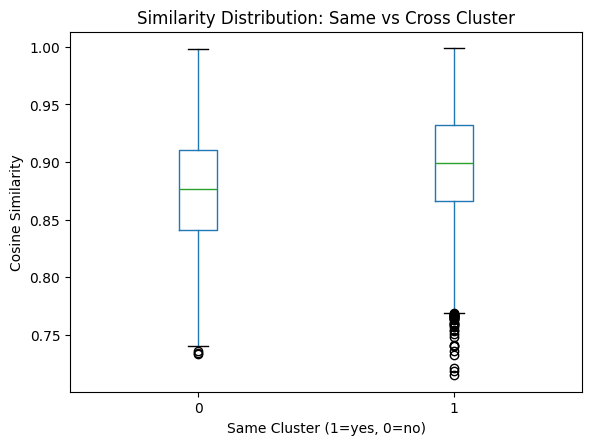

In [23]:
# Count totals
total_pairs = len(topk_df)
same = (topk_df["same_cluster"] == 1).sum()
cross = (topk_df["same_cluster"] == 0).sum()

print(f"Total top-k edges: {total_pairs}")
print(f"Same-cluster: {same} ({same/total_pairs:.1%})")
print(f"Cross-cluster: {cross} ({cross/total_pairs:.1%})")

# Average similarity by type
print("\nAverage similarity by group:")
print(topk_df.groupby("same_cluster")["sim_cosine"].mean())

# Distribution summary
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
topk_df.boxplot(column="sim_cosine", by="same_cluster", grid=False)
plt.title("Similarity Distribution: Same vs Cross Cluster")
plt.suptitle("")
plt.xlabel("Same Cluster (1=yes, 0=no)")
plt.ylabel("Cosine Similarity")
plt.show()


In [24]:
from scipy.stats import ttest_ind, mannwhitneyu

# Extract arrays
same_vals = topk_df.loc[topk_df["same_cluster"] == 1, "sim_cosine"]
cross_vals = topk_df.loc[topk_df["same_cluster"] == 0, "sim_cosine"]

print(f"Same-cluster mean = {same_vals.mean():.4f}, n = {len(same_vals)}")
print(f"Cross-cluster mean = {cross_vals.mean():.4f}, n = {len(cross_vals)}")

# Independent samples t-test (assumes roughly normal distribution)
t_stat, p_ttest = ttest_ind(same_vals, cross_vals, equal_var=False)
print(f"\nT-test: t = {t_stat:.3f}, p = {p_ttest:.4e}")

# Non-parametric alternative (Mann–Whitney U)
u_stat, p_u = mannwhitneyu(same_vals, cross_vals, alternative="two-sided")
print(f"Mann–Whitney U: U = {u_stat:.3f}, p = {p_u:.4e}")


Same-cluster mean = 0.8983, n = 15446
Cross-cluster mean = 0.8760, n = 4554

T-test: t = 28.112, p = 4.2746e-165
Mann–Whitney U: U = 44337950.000, p = 6.5601e-158


In [25]:
# Effect size (Cohen's d)
import numpy as np

mean_diff = same_vals.mean() - cross_vals.mean()
pooled_sd = np.sqrt(((same_vals.std()**2) + (cross_vals.std()**2)) / 2)
cohen_d = mean_diff / pooled_sd
print(f"Cohen's d = {cohen_d:.3f}")


Cohen's d = 0.479
